# MFCC

In [17]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio

In [19]:
dataset_path= "/home/iva/Desktop/ri/wake-word-detection/DATASET-WAKE-WORD-DETECTION"
wake_word= "stop"

wake_word_folder= os.path.join(
    dataset_path,
    wake_word
)

files= os.listdir(wake_word_folder)

#example file
audio_file= os.path.join(
    wake_word_folder,
    files[66]
)

print(audio_file)

/home/iva/Desktop/ri/wake-word-detection/DATASET-WAKE-WORD-DETECTION/stop/471a0925_nohash_3.wav


In [20]:
signal, sr= librosa.load(
    audio_file,
    sr=16000
)

print("Sample rate:", sr)

print("Signal shape:", signal.shape)

Sample rate: 16000
Signal shape: (16000,)


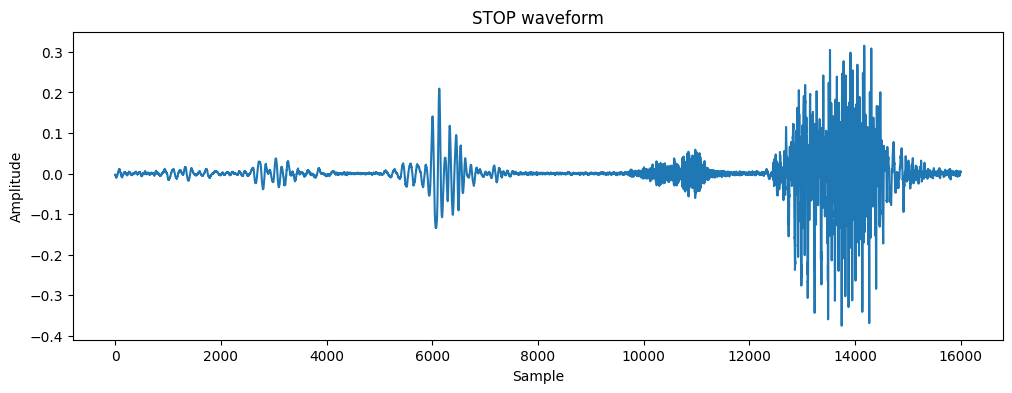

In [21]:
plt.figure(figsize=(12,4))
plt.plot(signal)
plt.title("STOP waveform")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

In [22]:
Audio(signal, rate=sr)

In [23]:
mfcc= librosa.feature.mfcc(
    y=signal,
    sr=sr,
    n_mfcc=13
)

print(mfcc.shape)

(13, 32)


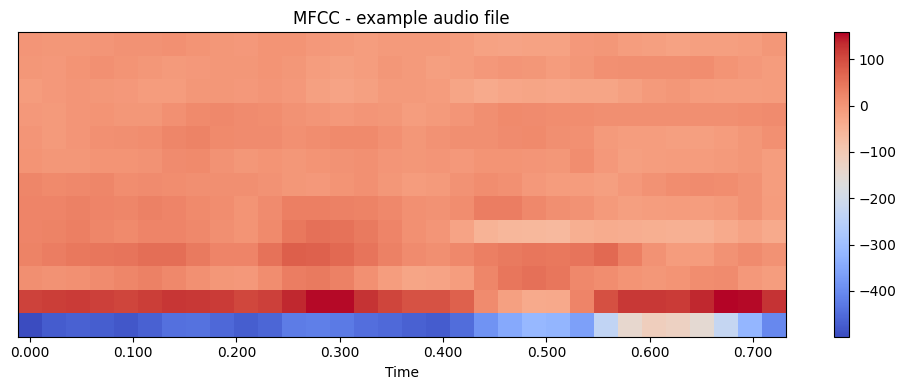

In [24]:
plt.figure(figsize=(10,4))
librosa.display.specshow(
    mfcc,
    x_axis='time'
)

plt.colorbar()
plt.title("MFCC - example audio file")
plt.tight_layout()
plt.show()

In [25]:
def extract_mfcc(file_path, n_mfcc=13, max_len=32):
    signal, sr= librosa.load(
        file_path,
        sr=16000
    )

    mfcc= librosa.feature.mfcc(
        y=signal,
        sr=sr,
        n_mfcc=n_mfcc
    )

    
    if mfcc.shape[1] < max_len:
        pad_width= max_len - mfcc.shape[1]

        mfcc= np.pad(
            mfcc,
            pad_width=((0,0),(0,pad_width)),
            mode='constant'
        )
    else:
        mfcc= mfcc[:, :max_len]

    return mfcc

In [26]:
X= []
y= []

In [27]:
for file_name in os.listdir(wake_word_folder):
    if file_name.endswith(".wav"):
        file_path= os.path.join(
            wake_word_folder,
            file_name
        )

        mfcc= extract_mfcc(file_path)

        X.append(mfcc)
        y.append(1)

In [28]:
for folder_name in os.listdir(dataset_path):
    folder_path= os.path.join(
        dataset_path,
        folder_name
    )

    if not os.path.isdir(folder_path):
        continue

    if folder_name == wake_word:
        continue

    if folder_name.startswith("_"):
        continue

    for file_name in os.listdir(folder_path):
        if file_name.endswith(".wav"):
            file_path= os.path.join(
                folder_path,
                file_name
            )

            mfcc = extract_mfcc(file_path)

            X.append(mfcc)
            y.append(0)

In [29]:
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (61755, 13, 32)
y shape: (61755,)


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (46316, 13, 32)
X_test: (15439, 13, 32)
y_train: (46316,)
y_test: (15439,)


# LFCC

In [31]:
import os
import numpy as np
import librosa
import scipy.fftpack

In [32]:
def extract_lfcc(
    file_path,
    n_lfcc=13,
    n_fft=512,
    hop_length=256,
    max_len=32
):

    signal, sr = librosa.load(
        file_path,
        sr=16000
    )

    stft = np.abs(
        librosa.stft(
            signal,
            n_fft=n_fft,
            hop_length=hop_length
        )
    )

    spectrogram = stft ** 2

    n_filters = 40

    freqs = np.linspace(
        0,
        sr // 2,
        n_filters + 2
    )

    fft_freqs = librosa.fft_frequencies(
        sr=sr,
        n_fft=n_fft
    )

    filter_bank = np.zeros(
        (n_filters, len(fft_freqs))
    )

    for i in range(1, n_filters + 1):

        left = freqs[i - 1]
        center = freqs[i]
        right = freqs[i + 1]

        for j, freq in enumerate(fft_freqs):

            if left <= freq <= center:

                filter_bank[i - 1, j] = (
                    (freq - left)
                    / (center - left)
                )

            elif center <= freq <= right:

                filter_bank[i - 1, j] = (
                    (right - freq)
                    / (right - center)
                )

    filtered_spectrum = np.dot(
        filter_bank,
        spectrogram
    )

    log_spectrum = np.log(
        filtered_spectrum + 1e-10
    )

    lfcc = scipy.fftpack.dct(
        log_spectrum,
        axis=0,
        norm='ortho'
    )

    lfcc = lfcc[:n_lfcc]

    if lfcc.shape[1] < max_len:

        pad_width = max_len - lfcc.shape[1]

        lfcc = np.pad(
            lfcc,
            pad_width=((0,0),(0,pad_width)),
            mode='constant'
        )

    else:

        lfcc = lfcc[:, :max_len]

    return lfcc

In [35]:
audio_file = os.path.join(
    dataset_path,
    "stop",
    os.listdir(
        os.path.join(dataset_path, "stop")
    )[0]
)

lfcc = extract_lfcc(audio_file)

print(lfcc.shape)

(13, 32)


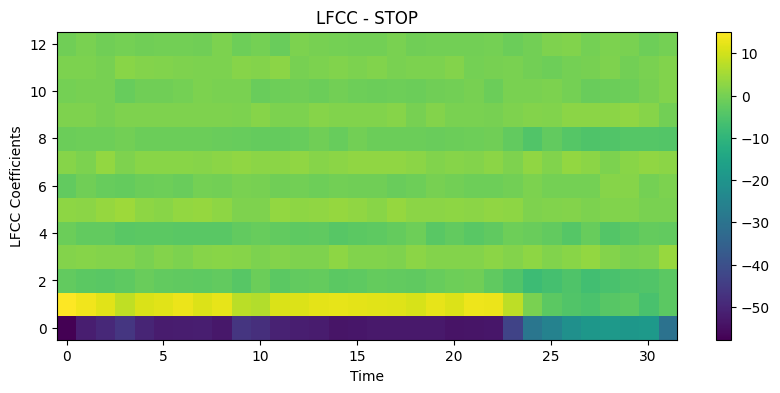

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.imshow(
    lfcc,
    aspect='auto',
    origin='lower'
)

plt.colorbar()
plt.title("LFCC - STOP")
plt.xlabel("Time")
plt.ylabel("LFCC Coefficients")
plt.show()

In [37]:
X_lfcc = []
y_lfcc = []

In [39]:
stop_folder = os.path.join(
    dataset_path,
    "stop"
)

for file_name in os.listdir(stop_folder):

    if file_name.endswith(".wav"):

        file_path = os.path.join(
            stop_folder,
            file_name
        )

        lfcc = extract_lfcc(file_path)

        X_lfcc.append(lfcc)

        y_lfcc.append(1)

In [41]:
for folder_name in os.listdir(dataset_path):

    folder_path = os.path.join(
        dataset_path,
        folder_name
    )

    if not os.path.isdir(folder_path):
        continue

    if folder_name == "stop":
        continue

    if folder_name.startswith("_"):
        continue

    for file_name in os.listdir(folder_path):

        if file_name.endswith(".wav"):

            file_path = os.path.join(
                folder_path,
                file_name
            )

            lfcc = extract_lfcc(file_path)

            X_lfcc.append(lfcc)

            y_lfcc.append(0)

In [42]:
X_lfcc = np.array(X_lfcc)
y_lfcc = np.array(y_lfcc)

print(X_lfcc.shape)
print(y_lfcc.shape)

(61755, 13, 32)
(61755,)


In [44]:
from sklearn.model_selection import train_test_split

In [45]:
X_lfcc_train, X_lfcc_test, y_lfcc_train, y_lfcc_test = train_test_split(
    X_lfcc,
    y_lfcc,
    test_size=0.25,
    random_state=42,
    stratify=y_lfcc
)

print("X_lfcc_train:", X_lfcc_train.shape)
print("X_lfcc_test:", X_lfcc_test.shape)
print("y_lfcc_train:", y_lfcc_train.shape)
print("y_lfcc_test:", y_lfcc_test.shape)

X_lfcc_train: (46316, 13, 32)
X_lfcc_test: (15439, 13, 32)
y_lfcc_train: (46316,)
y_lfcc_test: (15439,)
